In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Task 1: Dataset Understanding

## Load the Dataset

The Netflix Movies and TV Shows dataset was loaded into a Pandas DataFrame using the `read_csv()` function.

## Display the First Five Rows

The `head()` function was used to display the first five rows of the dataset. This provides a quick overview of the dataset's structure, column names, and sample records.

In [4]:
df.shape

(8807, 12)

## Number of Rows and Columns

The dataset contains 8,807 rows and 12 columns.

- Rows represent individual Netflix titles.
- Columns represent different attributes of each title, such as title, director, cast, country, release year, and rating.

In [5]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

## Data Types of All Columns

The `dtypes` function was used to identify the data type of each column in the dataset. Understanding the data types helps determine which columns contain numerical values and which contain categorical or text data. This information is important during the data cleaning process because different data types require different cleaning techniques.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


### Output Interpretation

The `info()` function shows that the dataset contains **8,807 records** and **12 columns**. Most columns have the **string (`str`)** data type, while the **`release_year`** column is stored as an **integer (`int64`)**, making it the only numerical feature in the dataset.

The output also reveals that some columns contain missing values:

- `director` has **6,173** non-null values.
- `cast` has **7,982** non-null values.
- `country` has **7,976** non-null values.
- `date_added` has **8,797** non-null values.
- `rating` has **8,803** non-null values.
- `duration` has **8,804** non-null values.

The remaining columns contain complete data with no missing values. The dataset occupies approximately **825.8 KB** of memory.

In [7]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['release_year'], dtype='str')

## Numerical Features

Numerical features are columns that contain numeric values and can be used for mathematical calculations and statistical analysis.

In this dataset, there is only one numerical feature:

- `release_year`

In [8]:
df.select_dtypes(include=['object', 'string']).columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

## Categorical Features

Categorical features contain descriptive or text-based information rather than numerical values. These columns describe the characteristics of each Netflix title.

The dataset contains the following categorical features:

In [9]:
df["show_id"].is_unique

True

## Possible Unique Identifier (Primary Key)

A primary key is a column that uniquely identifies each record in a dataset.

In this dataset, the `show_id` column appears to be the unique identifier because each Netflix title has its own unique ID.

## Dataset Description

The Netflix Movies and TV Shows dataset contains information about movies and television shows available on Netflix. Each record represents a single title and includes attributes such as the title, type, director, cast, country of origin, date added to Netflix, release year, rating, duration, genre, and description.

This dataset can be used to analyze Netflix's content library, identify trends in movie and TV show releases, explore content distribution across countries, and perform data cleaning and exploratory data analysis.

# Data Cleaning

Data cleaning is a crucial step in the data analysis process. It involves identifying and correcting errors, inconsistencies, and missing values to improve the quality and reliability of the dataset. In this section, the Netflix dataset will be cleaned by handling missing values, removing duplicate records, standardizing data formats, validating data quality, and documenting all cleaning actions performed.

In [10]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Missing Values

The `isnull().sum()` function was used to identify the columns that contain missing values and to count the number of missing values in each column.

### Interpretation

The output shows that several columns contain missing values.

- `director` has **2,634** missing values.
- `cast` has **825** missing values.
- `country` has **831** missing values.
- `date_added` has **10** missing values.
- `rating` has **4** missing values.
- `duration` has **3** missing values.

The remaining columns do not contain any missing values. These missing values will be handled appropriately in the following steps.

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Missing Values

The `isnull().sum()` function was used to identify the columns containing missing values and count the number of missing entries in each column.

### Interpretation

The output shows that six columns contain missing values:

- **director:** 2,634 missing values
- **cast:** 825 missing values
- **country:** 831 missing values
- **date_added:** 10 missing values
- **rating:** 4 missing values
- **duration:** 3 missing values

The remaining columns do not contain any missing values. These missing values will be handled appropriately in the following steps to ensure the dataset is clean and ready for analysis.

In [12]:
df.fillna({
    "director": "Unknown",
    "cast": "Unknown",
    "country": "Unknown"
}, inplace=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## Handling Missing Values

The missing values in the `director`, `cast`, and `country` columns were handled using the `fillna()` function. Missing entries were replaced with **"Unknown"** to indicate that the information is unavailable.

### Reason for the Approach

The `director`, `cast`, and `country` columns contain categorical (text) data. Replacing missing values with **"Unknown"** preserves all records in the dataset while clearly indicating that the information is missing. This approach avoids unnecessary data loss that would occur if the rows were removed.

In [13]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

### Verification of Missing Values

The dataset was checked again after handling the missing values in the `director`, `cast`, and `country` columns. The results confirm that these columns no longer contain any missing values.

The remaining missing values are found in the following columns:

- `date_added` – 10 missing values
- `rating` – 4 missing values
- `duration` – 3 missing values

The next step is to clean the remaining missing values in these columns.

In [14]:
df.dropna(subset=["date_added"], inplace=True)

## Handling Missing Values in the `date_added` Column

The missing values in the `date_added` column were removed using the `dropna()` function.

### Reason for the Approach

The `date_added` column contained only **10 missing values**, which represents a very small portion of the dataset. Removing these records has a negligible impact on the dataset while ensuring that analyses involving the date content was added to Netflix are based on complete and reliable data.

In [15]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64

### Verification

The dataset was checked after removing rows with missing values in the `date_added` column. The results confirm that the `date_added` column no longer contains missing values.

The remaining missing values are found in the following columns:

- `rating` – 4 missing values
- `duration` – 3 missing values

The next step is to handle the remaining missing values in these columns.

In [16]:
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

## Handling Missing Values in the `duration` Column

The missing values in the `duration` column were filled using the **mode** (the most frequently occurring value) of the column.

### Reason for the Approach

The `duration` column is a categorical variable that contains values such as movie durations (e.g., "90 min") and TV show seasons (e.g., "1 Season"). Using the mode preserves the existing distribution of the data while ensuring that no missing values remain.

In [17]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        0
listed_in       0
description     0
dtype: int64

### Verification

The dataset was checked after handling the missing values in the `duration` column. The results confirm that all missing values have been successfully addressed.

The dataset no longer contains any missing values and is now complete and ready for the next stage of the data cleaning process.

In [18]:
df.duplicated().sum()

np.int64(0)

# Duplicate Records

Duplicate records were checked using the `duplicated().sum()` function to determine whether the dataset contained any identical rows.

### Interpretation

The output shows that the dataset contains **0 duplicate records**. Since no duplicate rows were found, no records were removed. The dataset is free of duplicate entries and is ready for the next stage of the data cleaning process.

In [19]:
df.drop_duplicates(inplace=True)

# Standardization

## Column Names

The column names were reviewed to check whether they follow a consistent naming convention. This helps ensure that the dataset is well-structured and that the column names are clear, consistent, and easy to reference during analysis.

In [21]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

### Interpretation

The column names were found to be consistent. They are written in lowercase and use underscores (`_`) instead of spaces, making them clear, readable, and suitable for analysis. Therefore, no changes were required.

In [23]:
df["date_added"] = df["date_added"].str.strip()

In [24]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="mixed",
    errors="coerce"
)

### Date Format Standardization

The `date_added` column was standardized by removing unnecessary leading and trailing spaces before converting it to a datetime data type. This ensures that all dates follow a consistent format and can be used accurately for date-based analysis.

### Interpretation

The `date_added` column was successfully converted to the `datetime64[ns]` data type. Standardizing the date format improves data consistency and makes it easier to perform filtering, sorting, and time-based analysis.

In [25]:
text_columns = ["type", "title", "director", "cast", "country", "rating", "listed_in"]

for col in text_columns:
    df[col] = df[col].str.strip()

## Text Formatting

Leading and trailing spaces were removed from the text columns to ensure consistency across the dataset. This prevents issues caused by extra spaces when searching, filtering, grouping, or comparing text values.

### Interpretation

The text columns were successfully standardized by removing unnecessary whitespace. No additional formatting changes were required because the existing capitalization was already appropriate.

## Data Types

The data types of all columns were reviewed to ensure that each variable was stored in an appropriate format for analysis.

In [26]:
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object

### Interpretation

The data types were successfully reviewed after cleaning. The `release_year` column is stored as an integer (`int64`), the `date_added` column is stored as a datetime (`datetime64[us]`), and the remaining columns are stored as text (`str`). These data types are appropriate for the information contained in each column, so no further changes were required.

# Data Validation

The dataset was validated to identify any remaining missing values, invalid entries, inconsistent records, incorrect formats, or anomalies that could affect the quality of the analysis.

In [27]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        0
listed_in       0
description     0
dtype: int64

## Validation of Missing Values

After completing the data cleaning process, the dataset was checked again to identify any remaining missing values.

### Interpretation

The validation showed that all columns contained no missing values except the `rating` column, which still had **4 missing values**. These missing values were retained temporarily for further cleaning and were handled in the next step by replacing them with **"Unknown"**.

In [28]:
df["rating"] = df["rating"].fillna("Unknown")

In [29]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### Final Validation of Missing Values

The dataset was validated after handling the remaining missing values in the `rating` column.

### Interpretation

The validation confirms that all columns now contain **zero missing values**. All missing data has been successfully handled, and the dataset is complete and ready for further analysis.

In [30]:
df["type"].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

## Validating the `type` Column

The unique values in the `type` column were reviewed to identify any invalid or inconsistent entries.

### Interpretation

The `type` column contains only two valid categories: **Movie** and **TV Show**. No invalid or inconsistent values were found, therefore no changes were required.

In [31]:
df["rating"].unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',  'Unknown', 'TV-Y7-FV',       'UR']
Length: 18, dtype: str

## Validating the `rating` Column

The unique values in the `rating` column were reviewed to identify invalid or inconsistent entries.

### Interpretation

Most values in the `rating` column represent valid content ratings such as **PG-13**, **TV-MA**, and **TV-14**. However, a few entries (`74 min`, `84 min`, and `66 min`) represent movie durations rather than ratings. These values indicate data inconsistencies and require correction.

In [32]:
df[df["rating"].isin(["74 min", "84 min", "66 min"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,1 Season,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,1 Season,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,1 Season,Movies,The comic puts his trademark hilarious/thought...


In [33]:
mask = df["rating"].isin(["74 min", "84 min", "66 min"])

df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = "Unknown"

## Correcting Invalid Values

During data validation, a few records were found where movie durations (`74 min`, `84 min`, and `66 min`) were incorrectly stored in the `rating` column instead of the `duration` column.

These values were moved to the `duration` column, and the corresponding `rating` values were replaced with **"Unknown"** because the correct ratings were unavailable.

## Outliers and Anomalies

The dataset was reviewed for unusual or anomalous values. Since the dataset mainly consists of categorical variables, traditional outlier detection methods were not applicable.

The only notable anomaly identified was the presence of movie durations incorrectly stored in the `rating` column. This issue was corrected during the data validation process. No other significant anomalies were found.

# Cleaning Summary

In [34]:
import pandas as pd

summary = pd.DataFrame({
    "Issue Found": [
        "Missing Values",
        "Duplicate Records",
        "Invalid Entries",
        "Standardization"
    ],
    "Action Taken": [
        "Filled missing values in director, cast, country and rating with 'Unknown'. Removed rows with missing date_added.",
        "No duplicate records were found.",
        "Corrected movie durations that were mistakenly stored in the rating column.",
        "Standardized date formats, confirmed column names, and ensured correct data types."
    ]
})

summary

,Issue Found,Action Taken
0,Missing Values,"Filled missing values in director, cast, count..."
1,Duplicate Records,No duplicate records were found.
2,Invalid Entries,Corrected movie durations that were mistakenly...
3,Standardization,"Standardized date formats, confirmed column na..."


### Interpretation

The dataset was successfully cleaned and prepared for analysis. Missing values were handled appropriately, duplicate records were checked, invalid entries were corrected, and the dataset was standardized to ensure consistency and improve data quality.

In [35]:
text_columns = ["type", "director", "country", "rating", "listed_in"]

for col in text_columns:
    df[col] = df[col].str.strip()

### Text Formatting

The text columns were standardized by removing any leading or trailing spaces using the `str.strip()` function. No changes were made to uppercase or lowercase formatting because the dataset already used consistent and appropriate capitalization for movie titles, names, countries, and genres.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset by summarizing its main characteristics, identifying patterns, trends, and relationships within the data. The analysis provides meaningful insights that support data-driven decision-making.

In [36]:
df["release_year"].describe()

count    8797.000000
mean     2014.183472
std         8.822191
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

## Summary Statistics

The summary statistics provide an overview of the numerical data in the dataset.

The analysis focuses on the `release_year` column, which contains the year in which each movie or TV show was released. The statistics include the count, mean, standard deviation, minimum, maximum, and quartiles, helping to understand the distribution of release years.

In [37]:
df["release_year"].agg(["mean", "median", "min", "max", "std"])

mean      2014.183472
median    2017.000000
min       1925.000000
max       2021.000000
std          8.822191
Name: release_year, dtype: float64

### Interpretation

The statistics summarize the distribution of release years within the Netflix dataset. They indicate the average release year, the middle value, the earliest and latest releases, and the variation in release years.

In [38]:
df["type"].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

<Axes: xlabel='type'>

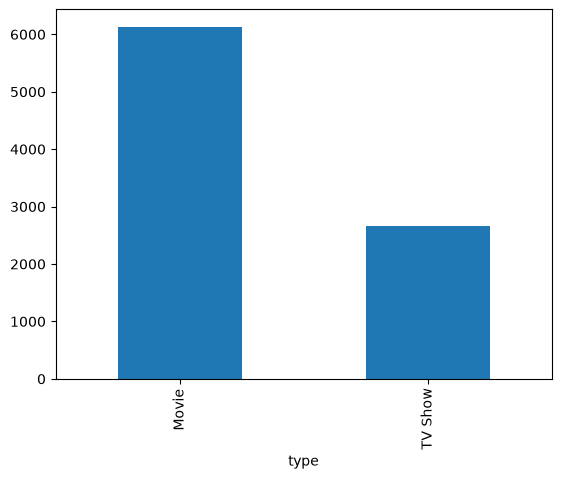

In [39]:
df["type"].value_counts().plot(kind="bar")

## Analysis 1: Movies vs TV Shows Distribution

This analysis compares the number of Movies and TV Shows available in the Netflix dataset.

The visualization helps identify which type of content is more common on Netflix.

In [40]:
df["date_added"].dt.year.value_counts().sort_index()

date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

<Axes: xlabel='date_added'>

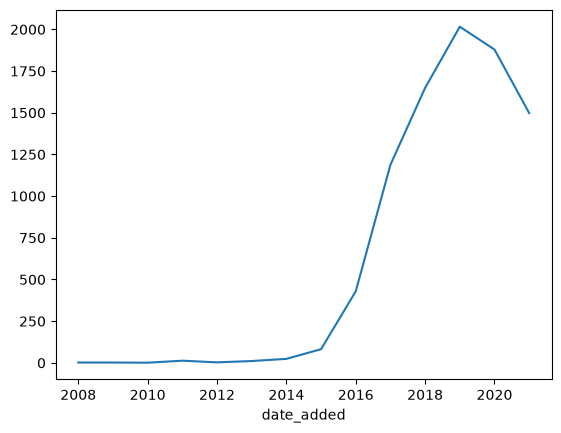

In [41]:
df["date_added"].dt.year.value_counts().sort_index().plot(kind="line")

## Analysis 2: Content Added by Year

This analysis examines the number of titles added to Netflix each year.

The trend helps identify periods when Netflix expanded its content library more rapidly.

In [42]:
df["country"].value_counts().head(10)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

<Axes: xlabel='country'>

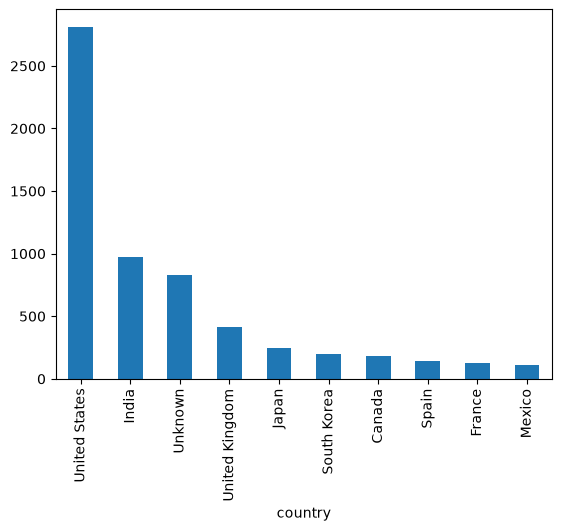

In [43]:
df["country"].value_counts().head(10).plot(kind="bar")

## Analysis 3: Top Content-Producing Countries

This analysis identifies the countries that contribute the highest number of titles to Netflix.

The results highlight the leading content-producing countries in the dataset.

In [44]:
df["rating"].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

<Axes: xlabel='rating'>

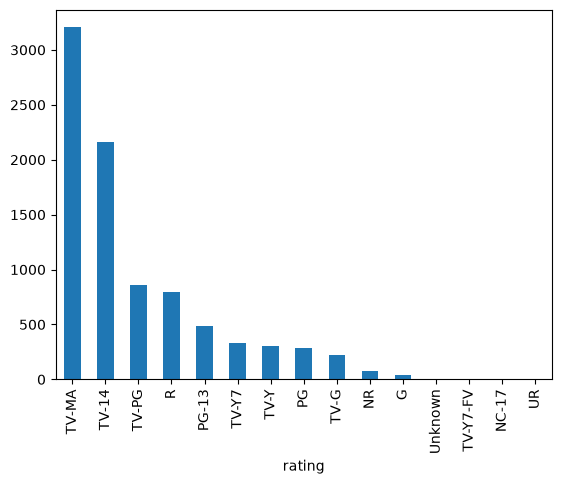

In [45]:
df["rating"].value_counts().plot(kind="bar")

## Analysis 4: Most Common Content Ratings

This analysis explores the distribution of content ratings such as TV-MA, TV-14, PG, and others.

It provides insight into the target audience for Netflix content.

In [46]:
df["listed_in"].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

<Axes: ylabel='listed_in'>

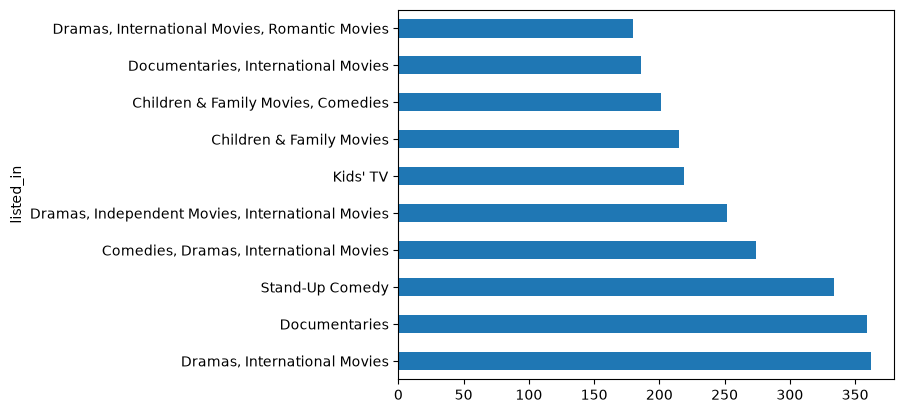

In [47]:
df["listed_in"].value_counts().head(10).plot(kind="barh")

## Analysis 5: Most Common Genres

This analysis identifies the most frequently occurring genres or categories in the Netflix dataset.

The results reveal the types of content that appear most often on Netflix.

## Analysis 1: Movies vs TV Shows Distribution

This analysis examines the distribution of Movies and TV Shows available in the Netflix dataset. Understanding the proportion of each content type provides insight into Netflix's content library.

In [48]:
df["type"].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

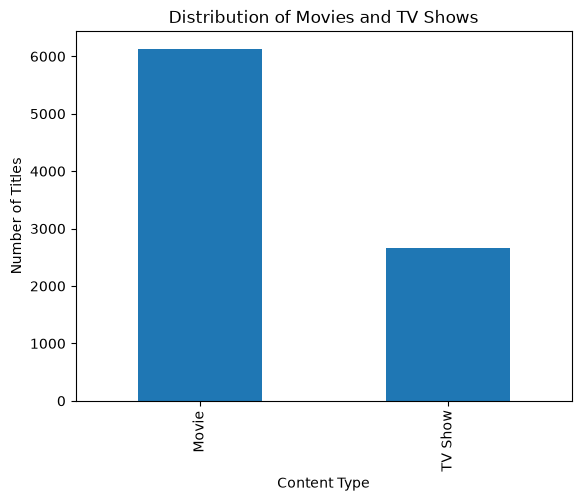

In [49]:
import matplotlib.pyplot as plt

df["type"].value_counts().plot(kind="bar")

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

### Interpretation

The chart shows the distribution of Movies and TV Shows in the Netflix dataset. Movies make up the largest proportion of the content library, while TV Shows account for a smaller share. This indicates that Netflix offers considerably more movies than TV shows.

## Analysis 2: Content Added by Year

This analysis examines the number of movies and TV shows added to Netflix each year. It helps identify trends in content additions over time and highlights periods of growth in Netflix's content library.

In [50]:
df["date_added"].dt.year.value_counts().sort_index()

date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

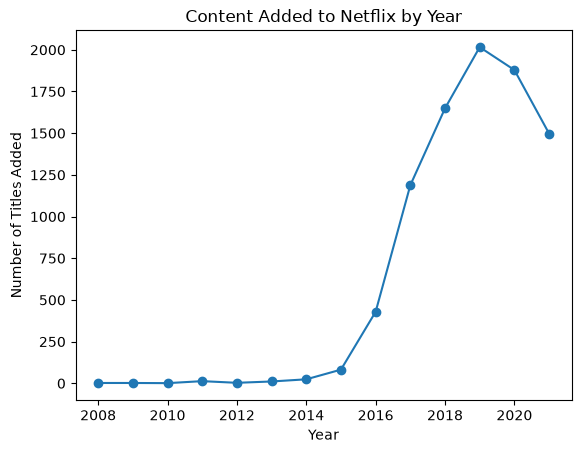

In [51]:
import matplotlib.pyplot as plt

content_by_year = df["date_added"].dt.year.value_counts().sort_index()

content_by_year.plot(kind="line", marker="o")

plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

### Interpretation

The chart illustrates the number of titles added to Netflix each year. The trend shows how Netflix expanded its content library over time, with periods of significant growth followed by changes in the number of titles added in later years.

## Analysis 3: Top Content-Producing Countries

This analysis identifies the countries that have produced the highest number of titles available on Netflix. It provides insight into the geographic distribution of Netflix content.

In [52]:
df["country"].value_counts().head(10)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

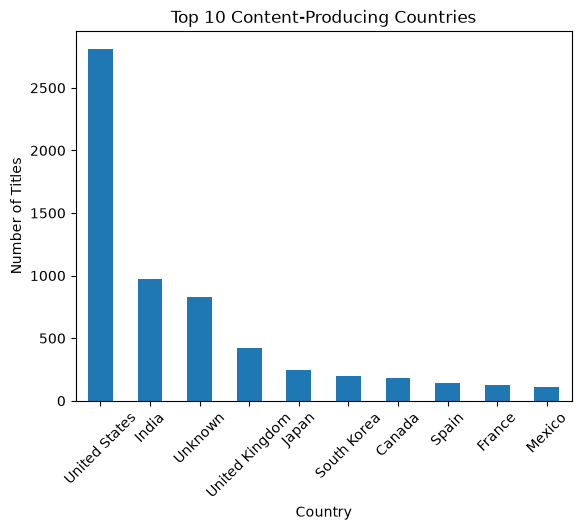

In [53]:
top_countries = df["country"].value_counts().head(10)

top_countries.plot(kind="bar")

plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

### Interpretation

The chart shows the top 10 countries that contribute the most content to Netflix. The leading countries have a significantly larger number of titles compared to the others, highlighting their strong presence in Netflix's content library.

## Analysis 4: Most Common Content Ratings

This analysis examines the distribution of content ratings in the Netflix dataset. Understanding the most common ratings provides insight into the target audience of Netflix's content library.

In [54]:
df["rating"].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

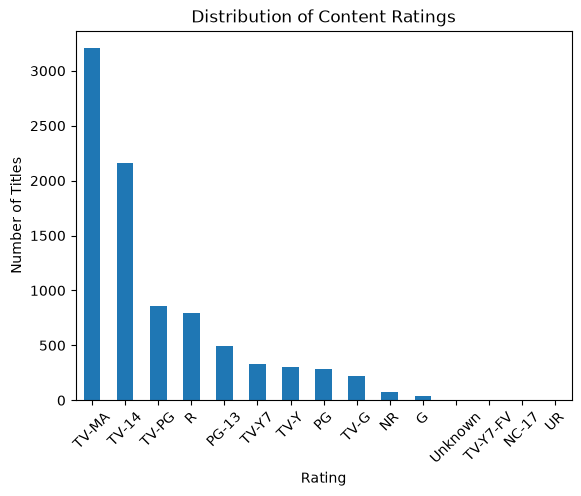

In [55]:
import matplotlib.pyplot as plt

ratings = df["rating"].value_counts()

ratings.plot(kind="bar")

plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

### Interpretation

The chart shows the distribution of content ratings available on Netflix. It highlights the most common ratings and provides insight into the age groups and audiences targeted by Netflix's content.

## Analysis 5: Most Common Genres/Categories

This analysis identifies the most frequently occurring genres and categories in the Netflix dataset. It helps reveal the types of content that dominate Netflix's library.

In [56]:
df["listed_in"].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

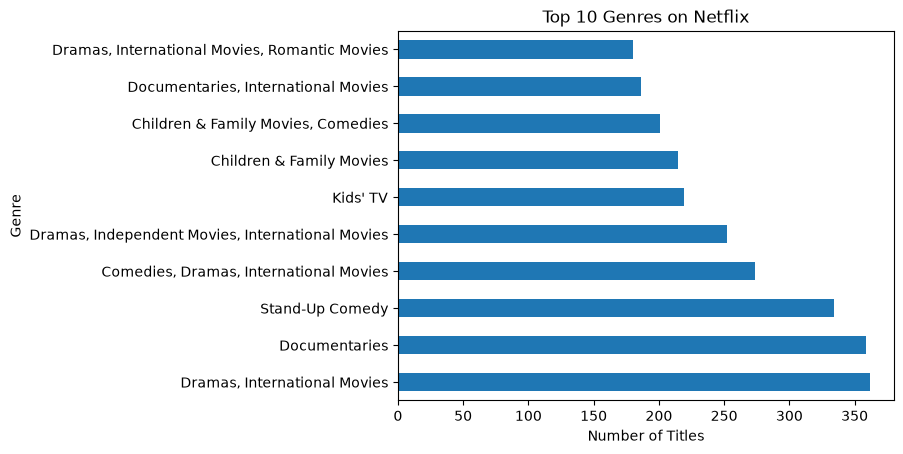

In [57]:
genres = df["listed_in"].value_counts().head(10)

genres.plot(kind="barh")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

### Interpretation

The chart displays the ten most common genres available on Netflix. These genres represent the categories that appear most frequently in the dataset, providing insight into the platform's content focus.

# Conclusion

The exploratory data analysis provided valuable insights into the Netflix dataset. The analysis showed that movies make up the majority of Netflix's content, content additions increased over the years, certain countries contribute more titles than others, and a few content ratings and genres dominate the platform. These findings demonstrate how exploratory data analysis can uncover meaningful patterns and trends that support data-driven decision-making.

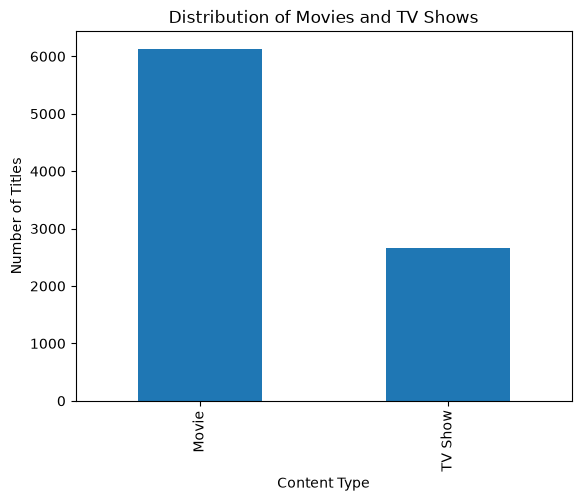

In [58]:
import matplotlib.pyplot as plt

df["type"].value_counts().plot(kind="bar")

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

### Findings

The bar chart shows that Netflix offers more movies than TV shows, indicating that movies make up the largest portion of the content library.

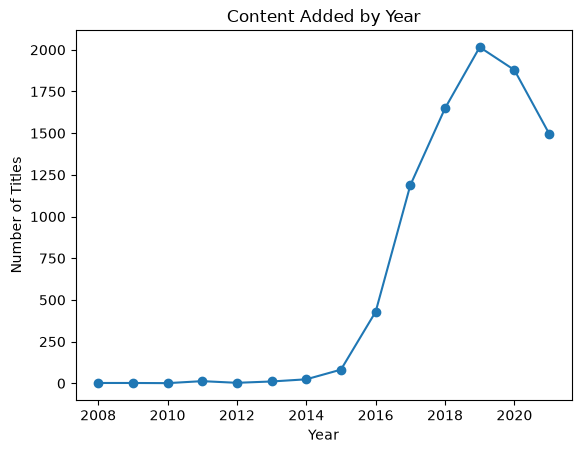

In [59]:
content_by_year = df["date_added"].dt.year.value_counts().sort_index()

content_by_year.plot(kind="line", marker="o")

plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

### Findings

The line chart shows how the number of titles added to Netflix has changed over time, highlighting periods of rapid growth in the content library.

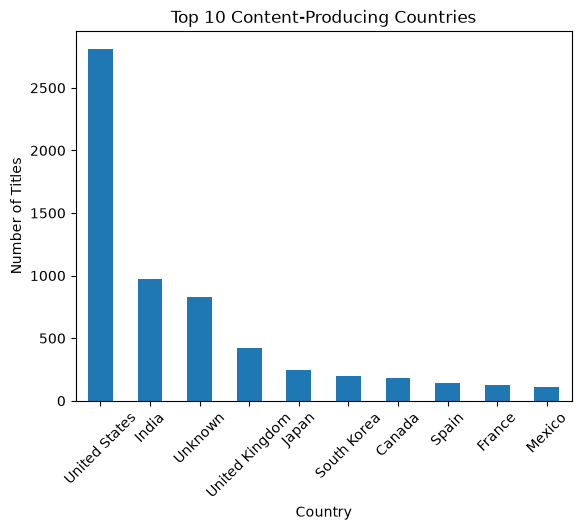

In [61]:
top_countries = df["country"].value_counts().head(10)

top_countries.plot(kind="bar")

plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

### Findings

The bar chart identifies the countries that contribute the highest number of titles to Netflix. A few countries dominate content production compared to others.

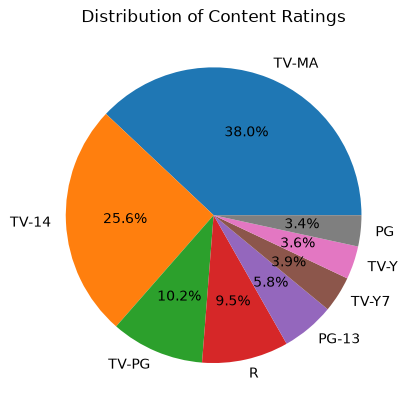

In [62]:
ratings = df["rating"].value_counts().head(8)

ratings.plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel=""
)

plt.title("Distribution of Content Ratings")
plt.show()

### Findings

The pie chart illustrates the proportion of different content ratings available on Netflix, showing which audience categories are most common.

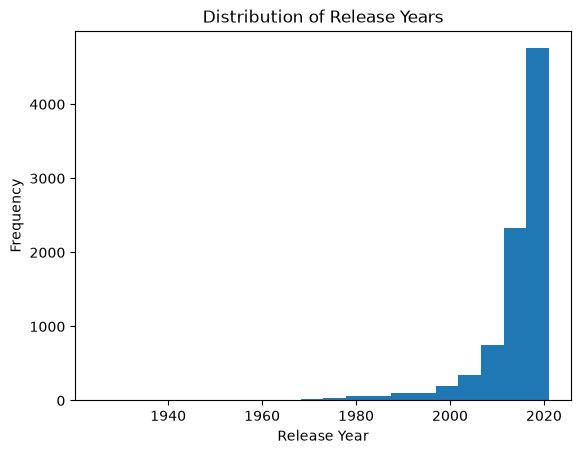

In [63]:
df["release_year"].plot(kind="hist", bins=20)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")

plt.show()

### Findings

The histogram shows how Netflix content is distributed across release years. It helps identify periods during which most of the available content was produced.

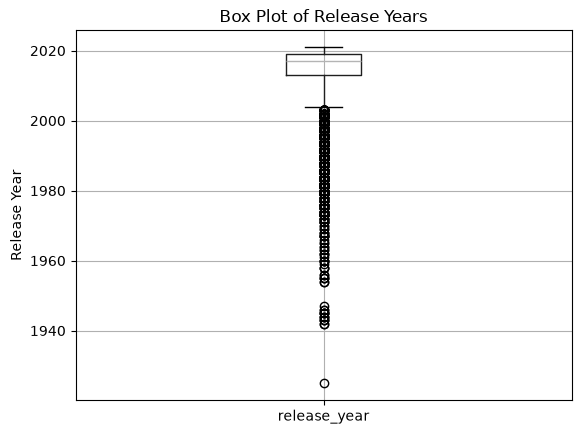

In [64]:
df.boxplot(column="release_year")

plt.title("Box Plot of Release Years")
plt.ylabel("Release Year")

plt.show()

### Findings

The box plot summarizes the distribution of release years and highlights the spread of the data as well as any potential outliers.

# Key Insights

The following insights were obtained from the exploratory data analysis of the Netflix dataset.

### Insight 1: Movies Make Up the Majority of Netflix's Content

The analysis of the **Movies vs TV Shows Distribution** revealed that movies significantly outnumber TV shows in the Netflix library. This indicates that Netflix's content catalog is primarily focused on movies, offering users a wider selection of films than television series.

**Supporting Analysis:** Analysis 1 – Movies vs TV Shows Distribution (Bar Chart)

### Insight 2: Netflix Experienced Significant Growth in Content Additions

The **Content Added by Year** analysis showed that the number of titles added to Netflix increased substantially over the years, demonstrating the platform's rapid expansion before stabilizing in more recent years.

**Supporting Analysis:** Analysis 2 – Content Added by Year (Line Chart)

### Insight 3: Content Production Is Concentrated in a Few Countries

The analysis of the **Top Content-Producing Countries** showed that a small number of countries contribute the majority of titles available on Netflix. This suggests that Netflix relies heavily on content produced in these countries.

**Supporting Analysis:** Analysis 3 – Top Content-Producing Countries (Bar Chart)

### Insight 4: Netflix Offers a Large Amount of Content for Mature Audiences

The **Most Common Ratings** analysis indicated that ratings such as **TV-MA** and **TV-14** appear more frequently than other ratings. This suggests that a large proportion of Netflix's content is intended for teenagers and adult audiences.

**Supporting Analysis:** Analysis 4 – Most Common Ratings (Pie Chart)

### Insight 5: A Few Genres Dominate Netflix's Content Library

The **Most Common Genres/Categories** analysis revealed that some genres appear much more frequently than others. This indicates that Netflix places greater emphasis on popular genres to appeal to a broad audience.

**Supporting Analysis:** Analysis 5 – Most Common Genres/Categories (Bar Chart)

# Overall Conclusion

The Netflix dataset was successfully cleaned, validated, explored, and visualized. The analysis revealed that movies dominate the platform, content additions increased significantly over time, a few countries contribute most of the available titles, mature audience ratings are common, and several genres appear more frequently than others. These insights demonstrate how data analysis can uncover meaningful patterns that support informed decision-making.

In [65]:
df.to_csv("netflix_titles_cleaned.csv", index=False)